In [32]:
import psycopg2
import pandas as pd
from time import sleep
import matplotlib.pyplot as plt
from datetime import date
import numpy as np

import boto3
import json

In [44]:
print("Initializing S3 connection...")

ENDPOINT = "http://localhost:9000"
session = boto3.Session(
    aws_access_key_id="dev_admin",
    aws_secret_access_key="dev_password",
    region_name="ru-central1"
)

s3 = session.client(
    "s3",
    endpoint_url=ENDPOINT
)

print(f"S3 connection to MinIO established")

Initializing S3 connection...
S3 connection to MinIO established


In [45]:
s3r = boto3.resource(
    's3',
    endpoint_url='http://localhost:9000',
    aws_access_key_id="dev_admin",
    aws_secret_access_key="dev_password",
    region_name="ru-central1"
)

In [127]:
bulls_bucket = s3r.Bucket('bulletins')
bull_keys = [key.key for key in bulls_bucket.objects.all()]

len(bull_keys)

1321

In [128]:
bulls = []

for key in bull_keys:
    response = s3.get_object(Bucket='bulletins', Key=key)
    bulls.append(response['Body'].read().decode('utf-8'))


In [129]:
bulls = [json.loads(bull) for bull in bulls]

In [130]:
print(type(bulls[0]))

<class 'dict'>


In [131]:
bulls_df = pd.DataFrame(bulls)
bulls_df = bulls_df.drop(
        columns=["timeReceived", "bullUrl", "imageUrls", "config", "date", "imageIds"])

In [132]:
bulls_df

,manufacturer,model,year,engineCapacity,enginePower,engineType,transmissionType,wheelDrive,mileage,isNew,...,location,broken,noDocs,color,steering,passportIssues,ownedByCompany,hasPenalties,numOfOwners,numOfPreviousBulls
0,Mitsubishi,Lancer,2007,2.0,150.0,бензин,вариатор,передний,275000.0,False,...,Омск,False,False,черный,левый,False,False,False,6.0,NaN
1,Chevrolet,Lacetti,2007,1.4,95.0,бензин,механика,передний,231000.0,False,...,Омск,False,False,бежевый,левый,False,False,False,4.0,5.0
2,Volkswagen,Touareg,2013,3.6,249.0,бензин,АКПП,4WD,275000.0,False,...,Омск,False,False,коричневый,левый,False,False,False,4.0,3.0
3,Лада,4x4 2131 Нива,2018,1.7,83.0,бензин,механика,4WD,93666.0,False,...,Омск,False,False,черный,левый,False,False,False,3.0,5.0
4,Toyota,Corolla,2005,1.5,110.0,бензин,АКПП,передний,277777.0,False,...,Омск,False,False,серый,правый,False,False,False,4.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1316,Hyundai,Solaris,2016,1.4,107.0,бензин,АКПП,передний,320150.0,False,...,Омск,False,False,серый,левый,False,True,False,4.0,3.0
1317,Kia,Rio,2018,1.6,123.0,бензин,АКПП,передний,91000.0,False,...,Омск,False,False,бежевый,левый,False,False,False,1.0,NaN
1318,Toyota,RAV4,2013,2.0,146.0,бензин,вариатор,передний,241718.0,False,...,Омск,False,False,черный,левый,False,False,False,5.0,3.0
1319,Лада,Гранта,2018,1.6,106.0,бензин,робот,передний,65000.0,False,...,Омск,False,False,белый,левый,False,False,False,2.0,NaN


In [133]:
bulls_df.isna().sum()

manufacturer            0
model                   0
year                    0
engineCapacity          6
enginePower             7
engineType              2
transmissionType       19
wheelDrive              3
mileage                57
isNew                   0
byOrder                 0
noMileageInRussia       0
fromOwner               0
priceRub                0
location                0
broken                  0
noDocs                  0
color                  18
steering               24
passportIssues        125
ownedByCompany          0
hasPenalties            0
numOfOwners           143
numOfPreviousBulls    503
dtype: int64

In [134]:
print(f"Data quality: {round(100 * (bulls_df.dropna().shape[0]) / bulls_df.shape[0], 3)}%")
print(f"Quality rows left {bulls_df.dropna().shape[0]}")

Data quality: 56.17%
Quality rows left 742


In [135]:
bulls_df_no_prev_bulls = bulls_df.drop(columns=["numOfPreviousBulls"])
print(f"Data quality (no number_of_prev_bulls column): {round(100 * (bulls_df_no_prev_bulls.dropna().shape[0]) / bulls_df_no_prev_bulls.shape[0], 3)}%")
print(f"Quality rows left {bulls_df_no_prev_bulls.dropna().shape[0]}")

Data quality (no number_of_prev_bulls column): 81.302%
Quality rows left 1074


In [136]:
bulls_df.describe()

,year,engineCapacity,enginePower,mileage,priceRub,numOfOwners,numOfPreviousBulls
count,1321.000000,1315.000000,1314.000000,1264.000000,1.321000e+03,1178.000000,818.000000
mean,2011.108251,1.955513,141.134703,182878.028481,1.338952e+06,3.503396,4.869193
std,7.774449,0.764264,62.177970,104859.414077,1.678802e+06,2.233689,3.104268
min,1981.000000,0.700000,51.000000,1.000000,4.700000e+04,1.000000,2.000000
25%,2006.000000,1.500000,100.000000,100000.000000,4.500000e+05,2.000000,3.000000
50%,2011.000000,1.600000,125.000000,183000.000000,8.900000e+05,3.000000,4.000000
75%,2017.000000,2.000000,160.000000,250000.000000,1.650000e+06,5.000000,6.000000
max,2026.000000,6.200000,560.000000,828000.000000,2.400000e+07,15.000000,22.000000


In [137]:
bulls_df['carAge'] = date.today().year - bulls_df['year']

mileage_per_year = bulls_df['mileage'] / bulls_df['carAge']
avg_mileage_per_year = mileage_per_year.mean()

bulls_df['mileage'] = bulls_df['mileage'].fillna(avg_mileage_per_year)

bulls_df['numOfOwners'] = bulls_df['numOfOwners'].fillna(bulls_df['numOfOwners'].mean())
bulls_df['numOfPreviousBulls'] = bulls_df['numOfPreviousBulls'].fillna(bulls_df['numOfPreviousBulls'].mean())
bulls_df['engineType'] = bulls_df['engineType'].fillna(bulls_df['engineType'].mode()[0])
bulls_df['transmissionType'] = bulls_df['transmissionType'].fillna(np.random.choice(['АКПП', 'механика']))
bulls_df['wheelDrive'] = bulls_df['wheelDrive'].fillna(bulls_df['wheelDrive'].mode()[0])
bulls_df['steering'] = bulls_df['steering'].fillna(bulls_df['steering'].mode()[0])
bulls_df['steering'] = bulls_df['steering'].fillna(bulls_df['steering'].mode()[0])
bulls_df['color'] = bulls_df['color'].fillna(bulls_df['color'].mode()[0])
bulls_df['passportIssues'] = bulls_df['passportIssues'].fillna(bulls_df['passportIssues'].mode()[0])

bulls_df = bulls_df.dropna()

In [138]:
bulls_df.isna().sum()

manufacturer          0
model                 0
year                  0
engineCapacity        0
enginePower           0
engineType            0
transmissionType      0
wheelDrive            0
mileage               0
isNew                 0
byOrder               0
noMileageInRussia     0
fromOwner             0
priceRub              0
location              0
broken                0
noDocs                0
color                 0
steering              0
passportIssues        0
ownedByCompany        0
hasPenalties          0
numOfOwners           0
numOfPreviousBulls    0
carAge                0
dtype: int64

In [139]:
bulls_df

,manufacturer,model,year,engineCapacity,enginePower,engineType,transmissionType,wheelDrive,mileage,isNew,...,broken,noDocs,color,steering,passportIssues,ownedByCompany,hasPenalties,numOfOwners,numOfPreviousBulls,carAge
0,Mitsubishi,Lancer,2007,2.0,150.0,бензин,вариатор,передний,275000.0,False,...,False,False,черный,левый,False,False,False,6.0,4.869193,19
1,Chevrolet,Lacetti,2007,1.4,95.0,бензин,механика,передний,231000.0,False,...,False,False,бежевый,левый,False,False,False,4.0,5.000000,19
2,Volkswagen,Touareg,2013,3.6,249.0,бензин,АКПП,4WD,275000.0,False,...,False,False,коричневый,левый,False,False,False,4.0,3.000000,13
3,Лада,4x4 2131 Нива,2018,1.7,83.0,бензин,механика,4WD,93666.0,False,...,False,False,черный,левый,False,False,False,3.0,5.000000,8
4,Toyota,Corolla,2005,1.5,110.0,бензин,АКПП,передний,277777.0,False,...,False,False,серый,правый,False,False,False,4.0,9.000000,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1316,Hyundai,Solaris,2016,1.4,107.0,бензин,АКПП,передний,320150.0,False,...,False,False,серый,левый,False,True,False,4.0,3.000000,10
1317,Kia,Rio,2018,1.6,123.0,бензин,АКПП,передний,91000.0,False,...,False,False,бежевый,левый,False,False,False,1.0,4.869193,8
1318,Toyota,RAV4,2013,2.0,146.0,бензин,вариатор,передний,241718.0,False,...,False,False,черный,левый,False,False,False,5.0,3.000000,13
1319,Лада,Гранта,2018,1.6,106.0,бензин,робот,передний,65000.0,False,...,False,False,белый,левый,False,False,False,2.0,4.869193,8


In [140]:
y = bulls_df['priceRub']
X = bulls_df.drop(columns=['priceRub'])
print(X.shape)

(1314, 24)


In [141]:
def train_test_split(x, y, test_size):
    indices = np.random.choice(x.index, size=int(x.shape[0] * test_size), replace=False)
    x_test = x.iloc[indices]
    y_test = y.iloc[indices]

    x_train = x.drop(x.index[indices])
    y_train = y.drop(y.index[indices])

    return x_test, y_test, x_train, y_train

In [142]:
X_test, y_test, X_train, y_train = train_test_split(X, y, 0.15)

print(X_test.shape, y_test.shape, X_train.shape, y_train.shape)
print(X.shape, y.shape)

(197, 24) (197,) (1117, 24) (1117,)
(1314, 24) (1314,)


In [143]:
from catboost import CatBoostRegressor

category_names = ["manufacturer", "model", "engineType", "transmissionType", "wheelDrive", "isNew", "byOrder", "noMileageInRussia",
                  "fromOwner", "location", "broken", "noDocs", "color", "steering", "passportIssues", "ownedByCompany", "hasPenalties"
                 ]


In [144]:
model = CatBoostRegressor(
    cat_features=category_names,
    iterations=2000,
    learning_rate=0.1,
    depth=6,
    verbose=100
)

model.fit(X_train, y_train)

0:	learn: 1588945.1391300	total: 54.6ms	remaining: 1m 49s
100:	learn: 369148.3869623	total: 3.88s	remaining: 1m 12s
200:	learn: 251413.6656152	total: 7.52s	remaining: 1m 7s
300:	learn: 194979.9583678	total: 12.2s	remaining: 1m 8s
400:	learn: 163285.0514960	total: 17.2s	remaining: 1m 8s
500:	learn: 141768.7650001	total: 21.4s	remaining: 1m 4s
600:	learn: 124643.1841151	total: 25.1s	remaining: 58.5s
700:	learn: 110272.7377032	total: 28.7s	remaining: 53.2s
800:	learn: 98733.0519420	total: 32.5s	remaining: 48.7s
900:	learn: 88506.0715196	total: 36.3s	remaining: 44.3s
1000:	learn: 79507.5554009	total: 40s	remaining: 39.9s
1100:	learn: 72745.5051713	total: 43.6s	remaining: 35.6s
1200:	learn: 65789.5869059	total: 47.2s	remaining: 31.4s
1300:	learn: 59638.7729316	total: 50.8s	remaining: 27.3s
1400:	learn: 54274.5589436	total: 54.4s	remaining: 23.3s
1500:	learn: 50365.2124041	total: 58s	remaining: 19.3s
1600:	learn: 46537.9865398	total: 1m 1s	remaining: 15.3s
1700:	learn: 43126.6351982	total: 1

CatBoostRegressor(cat_features=['manufacturer', 'model', 'engineType', 'transmissionType', 'wheelDrive', 'isNew', 'byOrder', 'noMileageInRussia', 'fromOwner', 'location', 'broken', 'noDocs', 'color', 'steering', 'passportIssues', 'ownedByCompany', 'hasPenalties'], depth=6, iterations=2000, learning_rate=0.1, loss_function='RMSE', verbose=100)

In [145]:
predict_prices = []
true_prices = []

X_test_ = X_test.reset_index(drop=True)
y_test_ = y_test.reset_index(drop=True)

for i in range(40, 80):
    true_prices.append(y_test_[i])
    predict_prices.append(model.predict(X_test_.loc[i]))


''

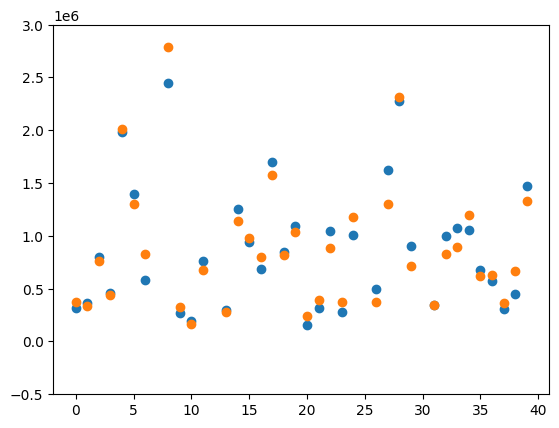

In [146]:
plt.scatter(range(40), true_prices)
plt.scatter(range(40), predict_prices)
plt.ylim(-500000, 3000000)
;

In [171]:
print(model.predict(X_test_.loc[78]))
print(y_test_.loc[78])
X_test_.loc[78]

668586.378003501
449000


manufacturer           Hyundai
model                 Santa Fe
year                      2004
engineCapacity             2.4
enginePower              138.0
engineType              бензин
transmissionType      механика
wheelDrive            передний
mileage               134000.0
isNew                    False
byOrder                  False
noMileageInRussia        False
fromOwner                False
location                  Омск
broken                   False
noDocs                   False
color                  голубой
steering                 левый
passportIssues           False
ownedByCompany           False
hasPenalties             False
numOfOwners                5.0
numOfPreviousBulls         5.0
carAge                      22
Name: 78, dtype: object

In [218]:
model.predict([
    'Nissan', 'Almera', 2005, 1.8, 116, 'бензин', 'механика', 'передний', 260000, False, False, False, True, 'Омск', False,
    False, 'черный', 'левый', False, False, False, 5, 4.84, 21
])

np.float64(480244.709366485)

In [149]:
importance_df = pd.DataFrame({
    'feature_name': X_test.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df

,feature_name,importance
4,enginePower,21.018817
23,carAge,15.813941
2,year,15.414482
3,engineCapacity,13.815543
8,mileage,8.350560
5,engineType,6.947660
0,manufacturer,4.696808
7,wheelDrive,4.065590
6,transmissionType,3.234234
16,color,1.756213
